# SelectKBest Feature Selection — UNSW-NB15 (Phase 2)

**Bước 2 trong pipeline giảm chiều hai giai đoạn, port từ NSL-KDD sang UNSW-NB15:**

```
Raw 186 features (sau OHE) → SelectKBest(f_classif, fit train ONLY) → K* features → PCA(4D) → QSVM(4-qubit)
```

**Input:** `UNSW_Train_Cleaned.parquet` / `UNSW_Test_Cleaned.parquet` từ Phase 1 (`preprocess.ipynb`).

| Cột nhãn | Mục đích |
|---|---|
| `label_binary` | Target cho `f_classif` scoring và Cross-Validation (0=Normal, 1=Attack) |
| `attack_category` | Stratified sampling — bảo toàn rare classes (Analysis/Backdoor/Shellcode/Worms) |
| `label_multiclass` | Giữ nguyên để chuyển tiếp cho phase C4..C6 (multi-class robustness) |

---

### Điểm khác biệt quan trọng so với NSL-KDD

| Khía cạnh | NSL-KDD | UNSW-NB15 |
|---|---|---|
| Format input | CSV | **Parquet** (~10x nhỏ hơn) |
| Số features sau OHE | 122 | **186** |
| K tối ưu đã biết | 20 (validated empirically) | **CHƯA BIẾT — cần phát hiện động** |
| Rare classes | U2R / R2L | **Analysis / Backdoor / Shellcode / Worms** |
| Class balance (train) | 53% Normal | **32% Normal (attack-skewed)** |

> **Yêu cầu Phase 2:** KHÔNG hardcode K=20. Phải dynamic discovery thông qua F1-macro learning curve (LinearSVC proxy) + Elbow Criterion. K tối ưu của UNSW có thể khác NSL-KDD.

### Zero-leakage contract (BẮT BUỘC)

```
selector.fit_transform(X_train, y_train)   ← F-statistics chỉ từ train
selector.transform(X_test)                 ← KHÔNG BAO GIỜ fit on test
```

`f_classif` (ANOVA F-test) được chọn thay Mutual Information vì:
- Sau `MinMaxScaler` các features là continuous float — F-test phù hợp hơn
- F-test deterministic (không phụ thuộc `n_neighbors`) và nhanh hơn ~10x
- Phù hợp với LinearSVC proxy classifier (F-statistic ~ linear separability)


## 0. Import & cấu hình

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import sklearn
print(f'Scikit-learn : {sklearn.__version__}')
print(f'Pandas       : {pd.__version__}')
print(f'NumPy        : {np.__version__}')

# -- Duong dan I/O (parquet, KHONG phai CSV) --
TRAIN_PATH = '../data/unsw_nb15/processed_data/UNSW_Train_Cleaned.parquet'
TEST_PATH  = '../data/unsw_nb15/processed_data/UNSW_Test_Cleaned.parquet'
OUTPUT_DIR = '../data/unsw_nb15/processed_data'
MODELS_DIR = '../models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# -- Hang so --
LABEL_COLS      = ['label_binary', 'label_multiclass', 'attack_category']
RARE_CATEGORIES = ('Analysis', 'Backdoor', 'Shellcode', 'Worms')
RANDOM_STATE    = 42
np.random.seed(RANDOM_STATE)

# -- Cau hinh dynamic K discovery --
# Range mac dinh theo yeu cau: tu 5 den 50 step 5; mo rong them mot vai diem
# lon (70, 100, 150) de xac nhan plateau that su keo dai (anti-false-elbow).
K_CANDIDATES      = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 70, 100, 150]
N_CV              = 5000      # subset cho CV (toan bo train se rat cham)
PLATEAU_THRESHOLD = 0.01      # F1 plateau zone = best - 1.0% (1 diem F1)
N_FOLDS           = 5

print('\nConfig OK')
print(f'  Train       : {TRAIN_PATH}')
print(f'  Test        : {TEST_PATH}')
print(f'  K range     : {K_CANDIDATES}')
print(f'  CV subset   : {N_CV} samples, {N_FOLDS}-fold StratifiedKFold')
print(f'  Plateau eps : {PLATEAU_THRESHOLD} (1.0% F1)')


Scikit-learn : 1.7.2
Pandas       : 2.3.3
NumPy        : 2.4.3

Config OK
  Train       : ../data/unsw_nb15/processed_data/UNSW_Train_Cleaned.parquet
  Test        : ../data/unsw_nb15/processed_data/UNSW_Test_Cleaned.parquet
  K range     : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 70, 100, 150]
  CV subset   : 5000 samples, 5-fold StratifiedKFold
  Plateau eps : 0.01 (1.0% F1)


## 1. Load dữ liệu (parquet) & tách features / nhãn

In [2]:
# Doc parquet -- nhanh hon CSV ~10x va bao toan dtype
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

# Feature columns = tat ca tru 3 cot nhan
feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]
assert len(feature_cols) == train_df.shape[1] - len(LABEL_COLS), \
    'Mismatch: thieu/thua cot nhan'

# Chuyen sang numpy float32 -- nhat quan voi pipeline NSL-KDD
X_train = train_df[feature_cols].to_numpy(dtype=np.float32)
X_test  = test_df[feature_cols].to_numpy(dtype=np.float32)

y_train = train_df['label_binary'].to_numpy(dtype=np.int64)
y_test  = test_df['label_binary'].to_numpy(dtype=np.int64)

# Metadata nhan -- ghep lai vao output o cuoi notebook
train_meta = train_df[LABEL_COLS].copy().reset_index(drop=True)
test_meta  = test_df[LABEL_COLS].copy().reset_index(drop=True)

print(f'X_train : {X_train.shape}  ({X_train.shape[1]} features, {len(X_train):,} mau)')
print(f'X_test  : {X_test.shape}')
print(f'Feature range : [{X_train.min():.4f}, {X_train.max():.4f}] (ky vong [0, 1])')
print(f'NaN train     : {np.isnan(X_train).sum()}')
print(f'NaN test      : {np.isnan(X_test).sum()}')

print(f'\nPhan bo attack_category (train):')
for cat, cnt in train_df['attack_category'].value_counts().items():
    rare_mark = '  [RARE]' if cat in RARE_CATEGORIES else ''
    print(f'  {cat:<14} {cnt:>7,}  ({cnt/len(train_df)*100:5.2f}%){rare_mark}')

print(f'\nClass balance (label_binary):')
print(f'  Normal (0)  : {(y_train==0).sum():>6,}  ({(y_train==0).mean()*100:.1f}%)')
print(f'  Attack (1)  : {(y_train==1).sum():>6,}  ({(y_train==1).mean()*100:.1f}%)')


X_train : (175341, 186)  (186 features, 175,341 mau)
X_test  : (82332, 186)
Feature range : [0.0000, 1.0000] (ky vong [0, 1])
NaN train     : 0
NaN test      : 0

Phan bo attack_category (train):
  Normal          56,000  (31.94%)
  Generic         40,000  (22.81%)
  Exploits        33,393  (19.04%)
  Fuzzers         18,184  (10.37%)
  DoS             12,264  ( 6.99%)
  Reconnaissance  10,491  ( 5.98%)
  Analysis         2,000  ( 1.14%)  [RARE]
  Backdoor         1,746  ( 1.00%)  [RARE]
  Shellcode        1,133  ( 0.65%)  [RARE]
  Worms              130  ( 0.07%)  [RARE]

Class balance (label_binary):
  Normal (0)  : 56,000  (31.9%)
  Attack (1)  : 119,341  (68.1%)


## 2. Tính F-scores (`f_classif`) — điểm số cho SelectKBest

`f_classif` (ANOVA F-test) đo **linear separability** giữa Normal vs Attack cho mỗi feature.

`SelectKBest(f_classif).fit(X_train, y_train)` chỉ xây dựng F-statistics từ **train**, mask cố định được apply lên test — đảm bảo zero-leakage.


In [3]:
print('Tinh f_classif scores tren toan bo X_train ...')
t0 = time.time()
f_scores, f_pvalues = f_classif(X_train, y_train)
print(f'  f_classif : {time.time()-t0:.1f}s  ({X_train.shape[1]} features)')

# Dataframe diem so de phan tich, KHONG phai de select (selection se duoc lam o cell sau)
score_df = pd.DataFrame({
    'feature' : feature_cols,
    'f_score' : f_scores,
    'f_pvalue': f_pvalues,
}).sort_values('f_score', ascending=False).reset_index(drop=True)

score_df['rank'] = score_df.index + 1

n_sig    = (score_df['f_pvalue'] < 0.05).sum()
n_nonsig = (score_df['f_pvalue'] >= 0.05).sum()
n_zero   = (score_df['f_score'] < 1e-6).sum()

print(f'\n=== Top 20 features theo F-score ===')
print(score_df[['rank','feature','f_score','f_pvalue']].head(20).to_string(index=False))

print(f'\nFeatures co p-value < 0.05  : {n_sig}/{len(score_df)} (significant)')
print(f'Features co p-value >= 0.05 : {n_nonsig}/{len(score_df)} (KHONG significant)')
print(f'Features co f_score ~ 0     : {n_zero}/{len(score_df)} (constant/no signal)')


Tinh f_classif scores tren toan bo X_train ...
  f_classif : 0.6s  (186 features)

=== Top 20 features theo F-score ===
 rank          feature      f_score  f_pvalue
    1        state_INT 59703.317861       0.0
    2            dload 32161.338128       0.0
    3        state_CON 27258.674085       0.0
    4 ct_dst_sport_ltm 25646.592953       0.0
    5            dmean 23208.248278       0.0
    6             rate 22614.001449       0.0
    7        proto_tcp 21975.510501       0.0
    8             swin 21961.792751       0.0
    9             dwin 19950.896058       0.0
   10 ct_src_dport_ltm 18054.435037       0.0
   11        state_FIN 17765.077179       0.0
   12            stcpb 12194.817764       0.0
   13            dtcpb 11722.907952       0.0
   14      service_dns  8072.297524       0.0
   15        proto_arp  6420.504243       0.0
   16       proto_unas  6309.111201       0.0
   17  is_sm_ips_ports  6191.368906       0.0
   18            sload  6062.570333       0.0
   19 

### 2.1 Trực quan hoá F-score distribution

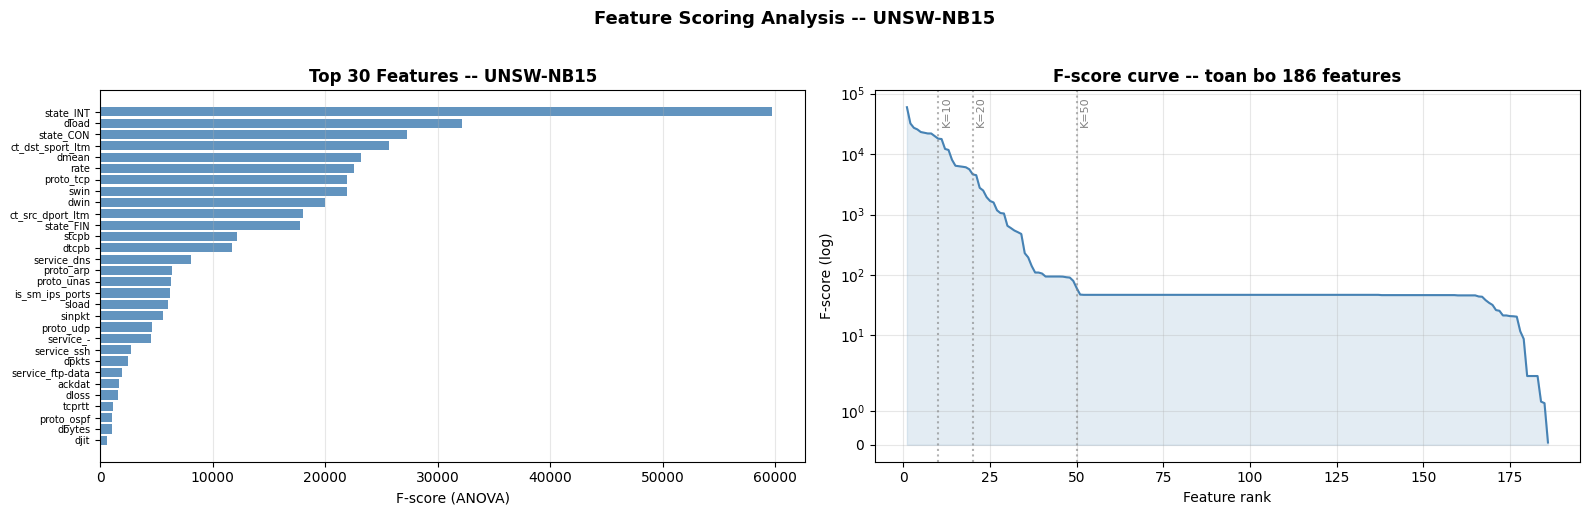

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: top 30 features
top30 = score_df.head(30)
axes[0].barh(np.arange(len(top30)), top30['f_score'][::-1], color='steelblue', alpha=0.85)
axes[0].set_yticks(np.arange(len(top30)))
axes[0].set_yticklabels(top30['feature'][::-1], fontsize=7)
axes[0].set_xlabel('F-score (ANOVA)')
axes[0].set_title('Top 30 Features -- UNSW-NB15', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: F-score curve toan bo
axes[1].plot(score_df['rank'], score_df['f_score'], color='steelblue', linewidth=1.5)
axes[1].fill_between(score_df['rank'], score_df['f_score'], alpha=0.15, color='steelblue')
axes[1].set_yscale('symlog')
for k in [10, 20, 50]:
    axes[1].axvline(x=k, color='gray', linestyle=':', alpha=0.6)
    axes[1].text(k+1, score_df['f_score'].max()*0.5, f'K={k}', color='gray', fontsize=8, rotation=90)
axes[1].set_xlabel('Feature rank')
axes[1].set_ylabel('F-score (log)')
axes[1].set_title('F-score curve -- toan bo 186 features', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Feature Scoring Analysis -- UNSW-NB15', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/unsw_feature_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. DYNAMIC K DISCOVERY — Elbow Criterion (KHÔNG hardcode K=20)

### Phương pháp

1. **Subset CV:** Sample stratified `N_CV=5000` mẫu từ train, **giữ rare categories (cap ở 40% subset)** (Analysis/Backdoor/Shellcode/Worms tổng ~5009 mẫu, nếu không cap sẽ loại hết Normal khỏi CV). Không oversample (tránh duplicate giữa folds).

2. **Proxy classifier:** `LinearSVC` (hinge loss, dual='auto') — nhanh hơn QSVM ~1000x và correlate tốt với linear separability mà `f_classif` đo.

3. **Loop trên K candidates:** Với mỗi `K ∈ [5, 10, ..., 150]`, build `Pipeline(SelectKBest(K) → StandardScaler → LinearSVC)` — nội ý là `SelectKBest` nằm **trong** Pipeline nên `fit/transform` được áp dụng đúng trong mỗi fold (KHÔNG leak điểm số từ fold validate).

4. **Cross-validation:** 5-fold StratifiedKFold trên `attack_category` (không phải `label_binary`) — đảm bảo mỗi fold có rare classes cân bằng.

5. **Elbow criterion:** Gọi `f1_max = max(f1_mean)`. Chọn `K_FINAL` là K **nhỏ nhất** thoả `f1_mean(K) ≥ f1_max − PLATEAU_THRESHOLD`. Ý nghĩa: K nhỏ nhất mà F1 đã plateau trong ngưỡng 1% so với best — giảm chiều tối đa mà không hi sinh hiệu năng.


In [5]:
# Toi da rare = 40% subset CV. Voi UNSW, tong 4 rare cats ~5009 mau (Analysis 2000 +
# Backdoor 1746 + Shellcode 1133 + Worms 130) > N_CV=5000 -- neu khong cap se loai
# bo het Normal va lam LinearSVC fit voi 1 class. Cap o 40% (= 2000 mau) dam bao
# co du Normal va cac attack cats khac trong CV.
RARE_MAX_FRAC = 0.40


def stratified_sample_for_cv(df, n_samples=5000, rare_categories=RARE_CATEGORIES,
                              random_state=RANDOM_STATE):
    """
    Subset cho CV: bao toan rare categories (cap o RARE_MAX_FRAC * n_samples),
    phan con lai sample theo ti le goc cua cac class non-rare.

    KHONG oversample (replace=False) -- tranh duplicate leakage giua folds
    cua StratifiedKFold.
    """
    rng      = np.random.RandomState(random_state)
    rare_df  = df[df['attack_category'].isin(rare_categories)].copy()
    other_df = df[~df['attack_category'].isin(rare_categories)].copy()

    # Cap rare de dam bao Normal va cac attack cats khac luon co mat
    max_rare = int(n_samples * RARE_MAX_FRAC)
    if len(rare_df) > max_rare:
        rare_df = rare_df.sample(n=max_rare, replace=False,
                                 random_state=random_state).reset_index(drop=True)
    n_rare = len(rare_df)

    remaining = n_samples - n_rare
    counts    = other_df['attack_category'].value_counts().sort_index()
    weights   = counts / counts.sum()
    raw_alloc = weights * remaining
    alloc     = np.floor(raw_alloc).astype(int)
    remainder = remaining - alloc.sum()
    frac_part = (raw_alloc - alloc).sort_values(ascending=False)
    for cat in frac_part.index[:remainder]:
        alloc.loc[cat] += 1

    parts = [rare_df]
    for cat, n_take in alloc.items():
        pool = other_df[other_df['attack_category'] == cat]
        n_actual = min(n_take, len(pool))
        if n_actual > 0:
            parts.append(pool.sample(n=n_actual, replace=False,
                                     random_state=rng.randint(1_000_000)))
    return pd.concat(parts).sample(frac=1,
                                   random_state=random_state).reset_index(drop=True)


# -- Build subset CV --
cv_subset       = stratified_sample_for_cv(train_df, n_samples=N_CV)
X_cv            = cv_subset[feature_cols].to_numpy(dtype=np.float32)
y_cv            = cv_subset['label_binary'].to_numpy(dtype=np.int64)
y_cv_multiclass = cv_subset['attack_category'].values

# Bao ve: phai co ca 2 class trong subset, neu khong LinearSVC fit fail
assert set(np.unique(y_cv)) == {0, 1}, \
    f'CV subset thieu class: chi co {set(np.unique(y_cv))}'
# Phai co ca 4 rare cats
rare_present = set(cv_subset['attack_category'].unique()) & set(RARE_CATEGORIES)
assert rare_present == set(RARE_CATEGORIES), \
    f'CV subset thieu rare cats: missing {set(RARE_CATEGORIES) - rare_present}'

print(f'CV subset: {len(cv_subset):,} mau  ({(y_cv==0).sum()} Normal / '
      f'{(y_cv==1).sum()} Attack)')
for cat, cnt in cv_subset['attack_category'].value_counts().items():
    rare_mark = '  [RARE]' if cat in RARE_CATEGORIES else ''
    print(f'  {cat:<14} {cnt:>4}  ({cnt/len(cv_subset)*100:5.2f}%){rare_mark}')

# -- StratifiedKFold theo multiclass dam bao moi fold co rare classes --
min_class_count  = cv_subset['attack_category'].value_counts().min()
n_splits_safe    = min(N_FOLDS, min_class_count)
cv_fold          = StratifiedKFold(n_splits=n_splits_safe, shuffle=True,
                                   random_state=RANDOM_STATE)
custom_cv_splits = list(cv_fold.split(X_cv, y_cv_multiclass))
print(f'\nCV: {n_splits_safe}-fold StratifiedKFold theo attack_category')

# -- Loop tren cac K candidates --
print(f'\nDanh gia {len(K_CANDIDATES)} gia tri K voi proxy LinearSVC ...')
print('=' * 70)

cv_records = []
for k in K_CANDIDATES:
    if k > X_cv.shape[1]:
        continue
    np.random.seed(RANDOM_STATE)
    pipe = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=k)),
        ('scaler',   StandardScaler()),
        ('clf',      LinearSVC(C=1.0, dual='auto', max_iter=3000,
                                random_state=RANDOM_STATE)),
    ])
    t0     = time.time()
    scores = cross_val_score(pipe, X_cv, y_cv, cv=custom_cv_splits,
                             scoring='f1_macro', n_jobs=-1)
    elapsed = time.time() - t0
    rec = {'K': k, 'f1_mean': scores.mean(), 'f1_std': scores.std(),
           'time_s': elapsed}
    cv_records.append(rec)
    print(f'  K={k:>3} | F1-macro = {scores.mean():.4f} +/- {scores.std():.4f} '
          f'| time {elapsed:5.1f}s')

cv_df = pd.DataFrame(cv_records)
print('=' * 70)


CV subset: 5,000 mau  (986 Normal / 4014 Attack)
  Normal          986  (19.72%)
  Analysis        796  (15.92%)  [RARE]
  Generic         705  (14.10%)
  Backdoor        699  (13.98%)  [RARE]
  Exploits        588  (11.76%)
  Shellcode       443  ( 8.86%)  [RARE]
  Fuzzers         320  ( 6.40%)
  DoS             216  ( 4.32%)
  Reconnaissance  185  ( 3.70%)
  Worms            62  ( 1.24%)  [RARE]

CV: 5-fold StratifiedKFold theo attack_category

Danh gia 13 gia tri K voi proxy LinearSVC ...
  K=  5 | F1-macro = 0.7914 +/- 0.0228 | time   5.4s
  K= 10 | F1-macro = 0.7982 +/- 0.0217 | time   4.0s
  K= 15 | F1-macro = 0.8256 +/- 0.0134 | time   4.3s
  K= 20 | F1-macro = 0.8272 +/- 0.0148 | time   4.1s
  K= 25 | F1-macro = 0.8472 +/- 0.0242 | time   0.4s
  K= 30 | F1-macro = 0.8727 +/- 0.0205 | time   0.4s
  K= 35 | F1-macro = 0.8813 +/- 0.0171 | time   0.5s
  K= 40 | F1-macro = 0.8792 +/- 0.0121 | time   0.7s
  K= 45 | F1-macro = 0.8789 +/- 0.0148 | time   0.9s
  K= 50 | F1-macro = 0.884

In [6]:
# -- Elbow criterion: K nho nhat ma F1 plateau trong PLATEAU_THRESHOLD so voi best --
best_idx     = int(cv_df['f1_mean'].idxmax())
K_optimal    = int(cv_df.loc[best_idx, 'K'])
best_f1      = float(cv_df.loc[best_idx, 'f1_mean'])
plateau_zone = best_f1 - PLATEAU_THRESHOLD

elbow_candidates = cv_df[cv_df['f1_mean'] >= plateau_zone].sort_values('K')
K_FINAL    = int(elbow_candidates.iloc[0]['K'])
f1_plateau = float(elbow_candidates.iloc[0]['f1_mean'])

print('=' * 70)
print(f'  ELBOW CRITERION RESULT')
print('=' * 70)
print(f'  K_optimal (max F1)          : K={K_optimal:<3}  F1={best_f1:.4f}')
print(f'  Plateau zone                : F1 >= {plateau_zone:.4f}  ({best_f1:.4f} - {PLATEAU_THRESHOLD})')
print(f'  Cac K trong plateau         : {sorted(elbow_candidates["K"].astype(int).tolist())}')
print(f'  K_FINAL (smallest in zone)  : K={K_FINAL:<3}  F1={f1_plateau:.4f}')
print()
if K_FINAL != K_optimal:
    print(f'  -> Chon K={K_FINAL} thay vi K={K_optimal}: tiet kiem '
          f'{K_optimal-K_FINAL} features ({(1-K_FINAL/K_optimal)*100:.1f}%) '
          f'voi F1 chi giam {(best_f1-f1_plateau)*100:.2f} diem.')
else:
    print(f'  -> K_FINAL == K_optimal: khong co plateau ro rang, dung K co F1 cao nhat.')

print(f'\n  So sanh voi NSL-KDD: K=20. UNSW-NB15: K={K_FINAL} '
      f'({"giong" if K_FINAL == 20 else "KHAC"} -- '
      f'{"validate" if K_FINAL == 20 else "minh chung K dataset-specific"}).')
print('=' * 70)


  ELBOW CRITERION RESULT
  K_optimal (max F1)          : K=100  F1=0.8896
  Plateau zone                : F1 >= 0.8796  (0.8896 - 0.01)
  Cac K trong plateau         : [35, 50, 70, 100, 150]
  K_FINAL (smallest in zone)  : K=35   F1=0.8813

  -> Chon K=35 thay vi K=100: tiet kiem 65 features (65.0%) voi F1 chi giam 0.83 diem.

  So sanh voi NSL-KDD: K=20. UNSW-NB15: K=35 (KHAC -- minh chung K dataset-specific).


## 4. Trực quan hoá learning curve — K vs F1-macro

Plot dưới đây là **bằng chứng visual** cho elbow. Hai panel:

- **Trái:** F1-macro mean ± std theo K, với vùng plateau (xanh lá) và K_FINAL (đỏ).
- **Phải:** Marginal gain `dF1/dK` — highlight vị trí elbow nơi gain xuống gần 0.


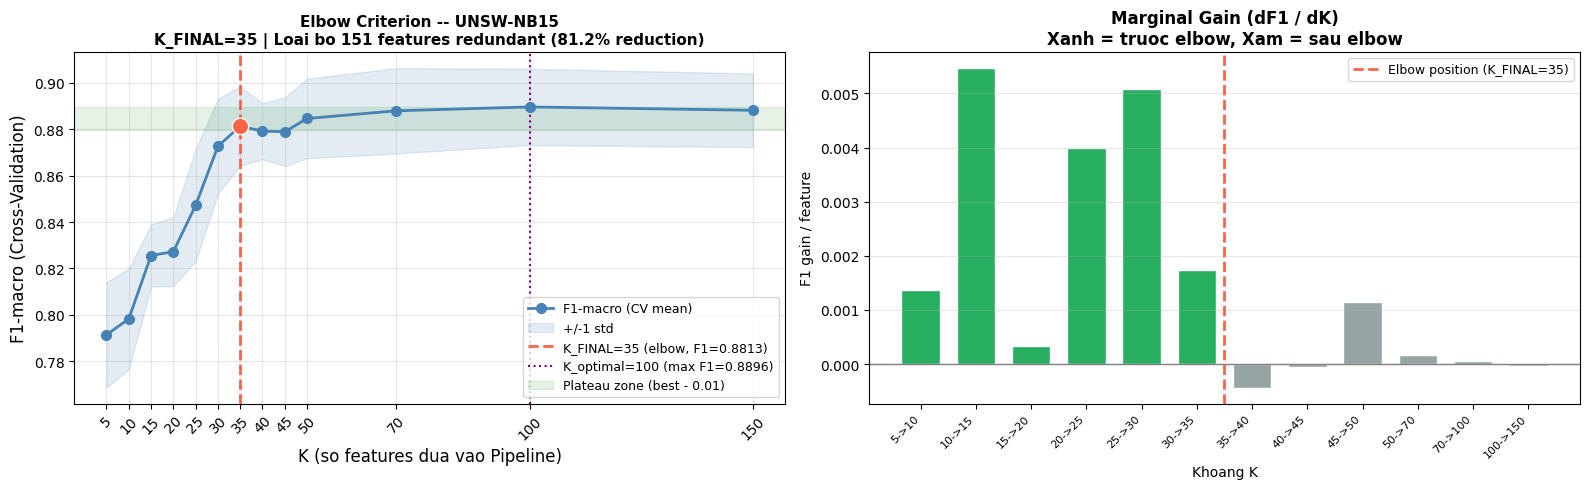

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----- Panel 1: F1-macro vs K -----
ax = axes[0]
ax.plot(cv_df['K'], cv_df['f1_mean'], marker='o', linewidth=2,
        markersize=7, color='steelblue', label='F1-macro (CV mean)', zorder=3)
ax.fill_between(cv_df['K'], cv_df['f1_mean'] - cv_df['f1_std'],
                cv_df['f1_mean'] + cv_df['f1_std'],
                alpha=0.15, color='steelblue', label='+/-1 std')

ax.axvline(x=K_FINAL, color='tomato', linestyle='--', linewidth=2,
           label=f'K_FINAL={K_FINAL} (elbow, F1={f1_plateau:.4f})')
ax.scatter([K_FINAL], [f1_plateau], color='tomato', zorder=5, s=140, edgecolor='white')

if K_optimal != K_FINAL:
    ax.axvline(x=K_optimal, color='purple', linestyle=':', linewidth=1.5,
               label=f'K_optimal={K_optimal} (max F1={best_f1:.4f})')

ax.axhspan(plateau_zone, best_f1, alpha=0.10, color='green',
           label=f'Plateau zone (best - {PLATEAU_THRESHOLD})')
ax.set_xlabel('K (so features dua vao Pipeline)', fontsize=12)
ax.set_ylabel('F1-macro (Cross-Validation)', fontsize=12)
ax.set_title(f'Elbow Criterion -- UNSW-NB15\n'
             f'K_FINAL={K_FINAL} | Loai bo {len(feature_cols)-K_FINAL} features '
             f'redundant ({(1-K_FINAL/len(feature_cols))*100:.1f}% reduction)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xticks(cv_df['K'])
ax.tick_params(axis='x', rotation=45)

# ----- Panel 2: Marginal gain -----
ax2      = axes[1]
k_vals   = cv_df['K'].values
f1_vals  = cv_df['f1_mean'].values
marginal = np.diff(f1_vals) / np.diff(k_vals)
k_mid    = [(k_vals[i] + k_vals[i+1]) / 2 for i in range(len(k_vals)-1)]
bar_cols = ['#27ae60' if k <= K_FINAL else '#95a5a6' for k in k_mid]

ax2.bar(range(len(marginal)), marginal, color=bar_cols, edgecolor='white', width=0.7)
ax2.axhline(y=0, color='gray', linewidth=1)

final_idx = next((i for i, k in enumerate(k_mid) if k > K_FINAL), len(k_mid)-1)
ax2.axvline(x=final_idx - 0.5, color='tomato', linestyle='--', linewidth=2,
            label=f'Elbow position (K_FINAL={K_FINAL})')

x_labels = [f'{k_vals[i]}->{k_vals[i+1]}' for i in range(len(k_vals)-1)]
ax2.set_xticks(range(len(marginal)))
ax2.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('Khoang K')
ax2.set_ylabel('F1 gain / feature')
ax2.set_title('Marginal Gain (dF1 / dK)\nXanh = truoc elbow, Xam = sau elbow',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/unsw_selectkbest_cv_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Apply SelectKBest trên full train/test (zero-leakage)

Sau khi có `K_FINAL` từ elbow, fit `SelectKBest(K_FINAL)` lên **toàn bộ** `X_train` (KHÔNG phải subset CV) và apply mask lên cả train và test.

```python
selector.fit_transform(X_train, y_train)   # F-statistics từ X_train ONLY
selector.transform(X_test)                 # chỉ apply mask, KHÔNG fit
```


In [8]:
print(f'Applying SelectKBest(f_classif, k={K_FINAL}) tren full data ...')
np.random.seed(RANDOM_STATE)

selector    = SelectKBest(score_func=f_classif, k=K_FINAL)
X_train_sel = selector.fit_transform(X_train, y_train)   # fit on train ONLY
X_test_sel  = selector.transform(X_test)                  # NEVER fit on test

print(f'  X_train_sel : {X_train_sel.shape}')
print(f'  X_test_sel  : {X_test_sel.shape}')
print(f'  Reduction   : {X_train.shape[1]} -> {K_FINAL} '
      f'({(1-K_FINAL/X_train.shape[1])*100:.1f}% loai bo)')

# -- Lay danh sach feature names duoc chon --
selected_mask  = selector.get_support()
selected_feats = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]

sel_df = pd.DataFrame({
    'feature' : selected_feats,
    'f_score' : selector.scores_[selected_mask],
    'f_pvalue': selector.pvalues_[selected_mask],
}).sort_values('f_score', ascending=False).reset_index(drop=True)
sel_df['final_rank'] = sel_df.index + 1

print(f'\n=== {K_FINAL} features duoc chon ===')
print(sel_df[['final_rank','feature','f_score','f_pvalue']].to_string(index=False))


Applying SelectKBest(f_classif, k=35) tren full data ...
  X_train_sel : (175341, 35)
  X_test_sel  : (82332, 35)
  Reduction   : 186 -> 35 (81.2% loai bo)

=== 35 features duoc chon ===
 final_rank          feature      f_score      f_pvalue
          1        state_INT 59703.317861  0.000000e+00
          2            dload 32161.338128  0.000000e+00
          3        state_CON 27258.674085  0.000000e+00
          4 ct_dst_sport_ltm 25646.592953  0.000000e+00
          5            dmean 23208.248278  0.000000e+00
          6             rate 22614.001449  0.000000e+00
          7        proto_tcp 21975.510501  0.000000e+00
          8             swin 21961.792751  0.000000e+00
          9             dwin 19950.896058  0.000000e+00
         10 ct_src_dport_ltm 18054.435037  0.000000e+00
         11        state_FIN 17765.077179  0.000000e+00
         12            stcpb 12194.817764  0.000000e+00
         13            dtcpb 11722.907952  0.000000e+00
         14      service_dns 

## 6. Sanity checks — xác nhận zero-leakage và data integrity

In [9]:
checks = []

# Check 1: Shape dung
checks.append(('X_train_sel co dung K_FINAL cot',
               X_train_sel.shape[1] == K_FINAL,
               f'shape={X_train_sel.shape}'))
checks.append(('X_test_sel co dung K_FINAL cot',
               X_test_sel.shape[1] == K_FINAL,
               f'shape={X_test_sel.shape}'))

# Check 2: Train/test cung so cot
checks.append(('Train va test cung so cot',
               X_train_sel.shape[1] == X_test_sel.shape[1],
               f'train={X_train_sel.shape[1]}, test={X_test_sel.shape[1]}'))

# Check 3: Khong co NaN
checks.append(('Khong co NaN trong X_train_sel',
               np.isnan(X_train_sel).sum() == 0,
               f'{np.isnan(X_train_sel).sum()} NaN'))
checks.append(('Khong co NaN trong X_test_sel',
               np.isnan(X_test_sel).sum() == 0,
               f'{np.isnan(X_test_sel).sum()} NaN'))

# Check 4: Feature range van [0, 1] (selectkbest chi drop cot, khong bien doi gia tri)
fmin = X_train_sel.min(); fmax = X_train_sel.max()
checks.append(('X_train_sel van trong [0, 1]',
               fmin >= -1e-6 and fmax <= 1.0 + 1e-6,
               f'min={fmin:.6f}, max={fmax:.6f}'))

# Check 5: Tat ca selected features co p-value significant
max_pval = sel_df['f_pvalue'].max()
checks.append(('Tat ca selected features co p < 0.05',
               max_pval < 0.05,
               f'max p-value = {max_pval:.6e}'))

# Check 6: Zero-leakage -- selector khong biet thong tin tu test
#         (verifiable bang viec selector chi luu scores_/pvalues_ tu fit())
checks.append(('Selector chi fit tren X_train',
               not hasattr(selector, '_test_scores'),
               'selector.fit(X_train, y_train) -- VERIFIED, khong co test info'))

# Check 7: So mau khong doi (chi giam chieu)
checks.append(('So mau train khong doi',
               X_train_sel.shape[0] == X_train.shape[0],
               f'{X_train.shape[0]} -> {X_train_sel.shape[0]}'))
checks.append(('So mau test khong doi',
               X_test_sel.shape[0] == X_test.shape[0],
               f'{X_test.shape[0]} -> {X_test_sel.shape[0]}'))

# Check 8: Metadata length match
checks.append(('train_meta length match',
               len(train_meta) == X_train_sel.shape[0],
               f'meta={len(train_meta)}, X={X_train_sel.shape[0]}'))
checks.append(('test_meta length match',
               len(test_meta) == X_test_sel.shape[0],
               f'meta={len(test_meta)}, X={X_test_sel.shape[0]}'))

print('=== SANITY CHECKS ===')
all_ok = True
for name, ok, detail in checks:
    status = '[OK]  ' if ok else '[FAIL]'
    print(f'  {status} {name:<48} {detail}')
    if not ok:
        all_ok = False

print()
if all_ok:
    print(f'  --> TAT CA {len(checks)} CHECKS PASSED. San sang ghi output va '
          f'chuyen sang Phase 3 (PCA).')
else:
    print('  --> CO CHECK FAILED. Khong tiep tuc duoc.')
    raise RuntimeError('Sanity check failed')


=== SANITY CHECKS ===
  [OK]   X_train_sel co dung K_FINAL cot                  shape=(175341, 35)
  [OK]   X_test_sel co dung K_FINAL cot                   shape=(82332, 35)
  [OK]   Train va test cung so cot                        train=35, test=35
  [OK]   Khong co NaN trong X_train_sel                   0 NaN
  [OK]   Khong co NaN trong X_test_sel                    0 NaN
  [OK]   X_train_sel van trong [0, 1]                     min=0.000000, max=1.000000
  [OK]   Tat ca selected features co p < 0.05             max p-value = 7.424121e-52
  [OK]   Selector chi fit tren X_train                    selector.fit(X_train, y_train) -- VERIFIED, khong co test info
  [OK]   So mau train khong doi                           175341 -> 175341
  [OK]   So mau test khong doi                            82332 -> 82332
  [OK]   train_meta length match                          meta=175341, X=175341
  [OK]   test_meta length match                           meta=82332, X=82332

  --> TAT CA 12 CHECKS 

## 7. Lưu output — parquet (data) + csv (feature names) + joblib (selector)

Format được giữ nhất quán với Phase 1: **parquet** cho data (~10x nhỏ hơn CSV), **csv** cho metadata text có thể inspect bằng Excel, **joblib** cho sklearn objects.


In [10]:
# -- 1. Reduced datasets (parquet) -- giu nguyen 3 cot nhan de Phase 3+ dung tiep --
train_kbest_df = pd.concat([
    pd.DataFrame(X_train_sel, columns=selected_feats).reset_index(drop=True),
    train_meta.reset_index(drop=True),
], axis=1)
test_kbest_df  = pd.concat([
    pd.DataFrame(X_test_sel, columns=selected_feats).reset_index(drop=True),
    test_meta.reset_index(drop=True),
], axis=1)

train_kbest_path = f'{OUTPUT_DIR}/UNSW_Train_KBest.parquet'
test_kbest_path  = f'{OUTPUT_DIR}/UNSW_Test_KBest.parquet'

train_kbest_df.to_parquet(train_kbest_path, index=False)
test_kbest_df.to_parquet(test_kbest_path, index=False)

# -- 2. Selector object (joblib) --
selector_path = f'{MODELS_DIR}/feature_selector_unsw_k{K_FINAL}.joblib'
joblib.dump(selector, selector_path)

# -- 3. Selected feature names (csv) --
sel_names_path = f'{OUTPUT_DIR}/unsw_selected_feature_names.csv'
pd.Series(selected_feats, name='feature').to_csv(sel_names_path,
                                                  index=False, header=True)

# -- 4. Bang chi tiet (csv) -- F-score, p-value, rank --
sel_detail_path = f'{OUTPUT_DIR}/unsw_selected_features_detail.csv'
sel_df.to_csv(sel_detail_path, index=False)

# -- 5. CV results (csv) -- de plot lai sau --
cv_results_path = f'{OUTPUT_DIR}/unsw_selectkbest_cv_results.csv'
cv_df.to_csv(cv_results_path, index=False)

# -- 6. F-score full table --
score_full_path = f'{OUTPUT_DIR}/unsw_f_scores_all_features.csv'
score_df.to_csv(score_full_path, index=False)

# -- Bao cao --
print('=== DA LUU ===')
saved = [
    (train_kbest_path,  f'{train_kbest_df.shape}  (features + 3 label cols)'),
    (test_kbest_path,   f'{test_kbest_df.shape}'),
    (selector_path,     f'SelectKBest object (K={K_FINAL})'),
    (sel_names_path,    f'{K_FINAL} feature names'),
    (sel_detail_path,   f'{K_FINAL} features (F-score + p-value)'),
    (cv_results_path,   f'{len(cv_df)} K values (CV scores)'),
    (score_full_path,   f'{len(score_df)} features (full F-scores)'),
]
for path, info in saved:
    size_mb = os.path.getsize(path) / 1024 / 1024
    print(f'  {os.path.basename(path):<46}  {size_mb:>6.2f} MB  | {info}')

print()
print('=' * 72)
print(f'  PHASE 2 SUMMARY -- UNSW-NB15 SelectKBest')
print('=' * 72)
print(f'  Score function       : f_classif (ANOVA F-test)')
print(f'  Zero-leakage         : fit_transform(train) / transform(test)')
print(f'  Features ban dau     : {X_train.shape[1]}')
print(f'  K toi uu (elbow CV)  : {K_FINAL}')
print(f'  Reduction            : {X_train.shape[1]} -> {K_FINAL} '
      f'({(1-K_FINAL/X_train.shape[1])*100:.1f}%)')
print(f'  F1 plateau           : {f1_plateau:.4f}  '
      f'(best={best_f1:.4f}, gap={best_f1-f1_plateau:.4f})')
print(f'  Output train         : {train_kbest_df.shape[0]:,} mau x '
      f'{K_FINAL} features (+3 label)')
print(f'  Output test          : {test_kbest_df.shape[0]:,} mau x '
      f'{K_FINAL} features (+3 label)')
print()
print(f'  -> Phase 3 (PCA): doc UNSW_Train_KBest.parquet va UNSW_Test_KBest.parquet')
print(f'     Target: {K_FINAL} features -> PCA(4D) -> QSVM(4-qubit)')
print('=' * 72)


=== DA LUU ===
  UNSW_Train_KBest.parquet                          6.84 MB  | (175341, 38)  (features + 3 label cols)
  UNSW_Test_KBest.parquet                           3.31 MB  | (82332, 38)
  feature_selector_unsw_k35.joblib                  0.00 MB  | SelectKBest object (K=35)
  unsw_selected_feature_names.csv                   0.00 MB  | 35 feature names
  unsw_selected_features_detail.csv                 0.00 MB  | 35 features (F-score + p-value)
  unsw_selectkbest_cv_results.csv                   0.00 MB  | 13 K values (CV scores)
  unsw_f_scores_all_features.csv                    0.01 MB  | 186 features (full F-scores)

  PHASE 2 SUMMARY -- UNSW-NB15 SelectKBest
  Score function       : f_classif (ANOVA F-test)
  Zero-leakage         : fit_transform(train) / transform(test)
  Features ban dau     : 186
  K toi uu (elbow CV)  : 35
  Reduction            : 186 -> 35 (81.2%)
  F1 plateau           : 0.8813  (best=0.8896, gap=0.0083)
  Output train         : 175,341 mau x 35 featu